<a href="https://colab.research.google.com/github/PunamBhatia/LogicMojo-AI-ML-April26-Punam/blob/main/ClusteringAssignment/ClusteringAssignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt

import sklearn
from sklearn.preprocessing  import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import cut_tree

import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')


import warnings
warnings.filterwarnings('ignore')

Mounted at /content/drive


In [3]:
df=pd.read_csv('/content/drive/MyDrive/LogicMojo/ClusteringAssignment/Country-data.csv')
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [4]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [5]:
df.info()
#there are no nulls or missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [6]:
#start data preparation
#'health', 'imports' and 'exports' are given as a percentage of Total GDPP so lets convert it into actual value
df['exports']=(df['exports'] * df['gdpp'])/100
df['health']=(df['health']*df['gdpp'])/100
df['imports']=(df['imports']*df['gdpp'])/100
df.head()


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,55.30,41.9174,248.297,1610,9.44,56.2,5.82,553
1,Albania,16.6,1145.20,267.8950,1987.740,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,1712.64,185.9820,1400.440,12900,16.10,76.5,2.89,4460
3,Angola,119.0,2199.19,100.6050,1514.370,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,5551.00,735.6600,7185.800,19100,1.44,76.8,2.13,12200


In [7]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,7420.618847,1056.733204,6588.352108,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,17973.885795,1801.408906,14710.810418,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,1.076920,12.821200,0.651092,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,447.140000,78.535500,640.215000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,1777.440000,321.886000,2045.580000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,7278.000000,976.940000,7719.600000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,183750.000000,8663.600000,149100.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


Features to assess: ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


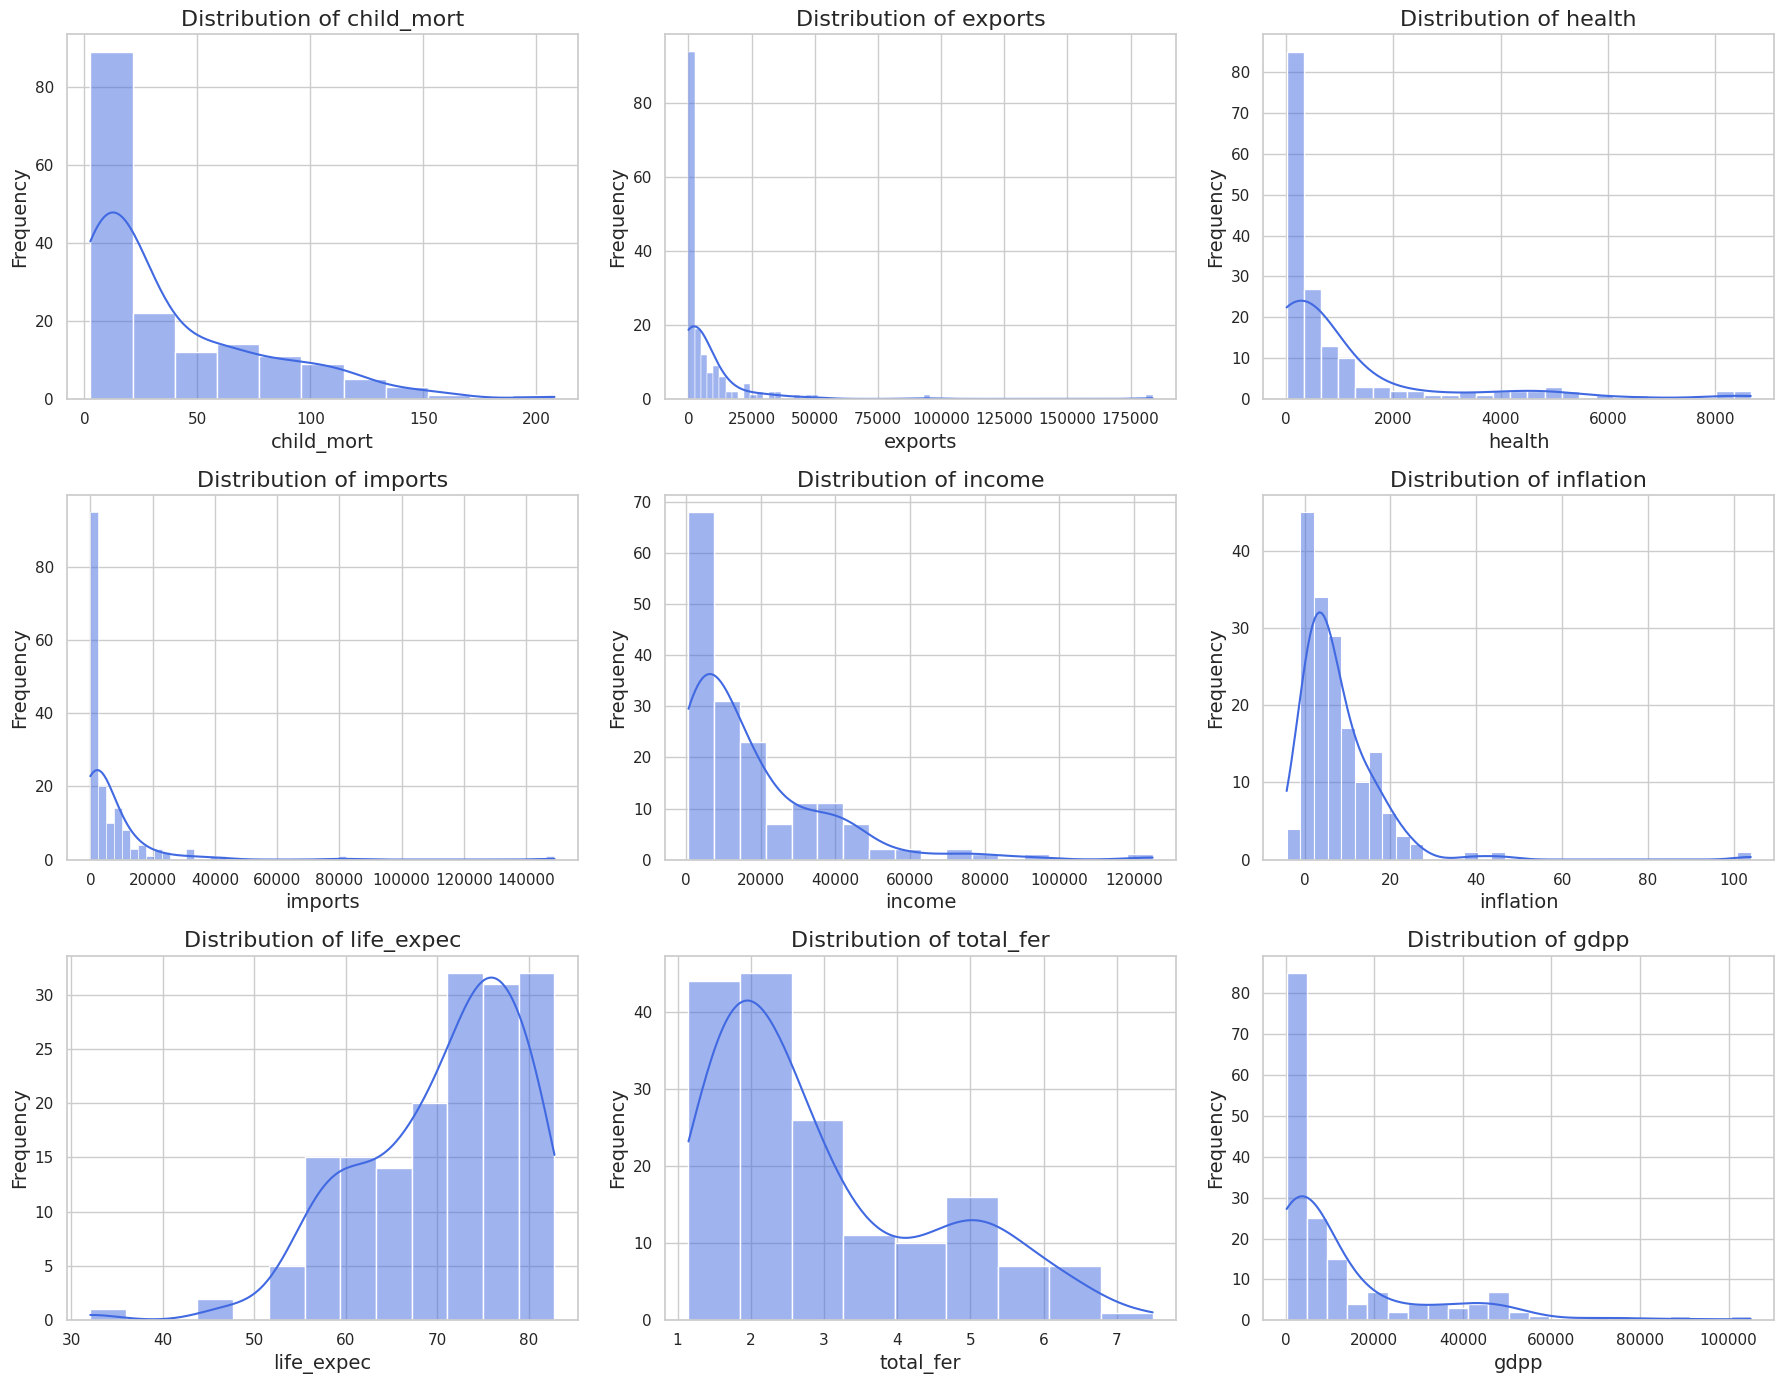

In [8]:
#let start distribution assessment
# Set the visual aesthetic for Seaborn
sns.set_theme(style="whitegrid")

numeric_features= df.select_dtypes(include=['int64', 'float64']).columns.to_list()
print('Features to assess:', numeric_features)

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18,14))
# Flatten the axes array from 2D (3x3) to 1D (9,) for easy looping
axes = axes.flatten()

#Lets plot histograma and Kernel Density Estimate (KDE) curve
for i, feature in enumerate(numeric_features):
    sns.histplot(data=df, x=feature, kde=True, color='royalblue', ax=axes[i])
    #sns.kdeplot( color='blue')

    # Customize the individual subplot titles and labels
    axes[i].set_title(f'Distribution of {feature}', fontsize=16)
    axes[i].set_xlabel(feature, fontsize=14)
    axes[i].set_ylabel('Frequency', fontsize=14)


# Adjust layout automatically so titles and labels don't overlap
plt.tight_layout()

# Display the final compilation of plots
plt.show()


# Inferences
1)  gdpp, income, imports, exports, health, child_mort are right skewed.This indicates a massive gap between a few wealthy/high-mortality countries and the rest of the world
2) life_expec is left skewed - most countries have a high life expectancy, but a small handful of struggling nations pull the distribution down
3) inflation has somewhat bell shaped curve

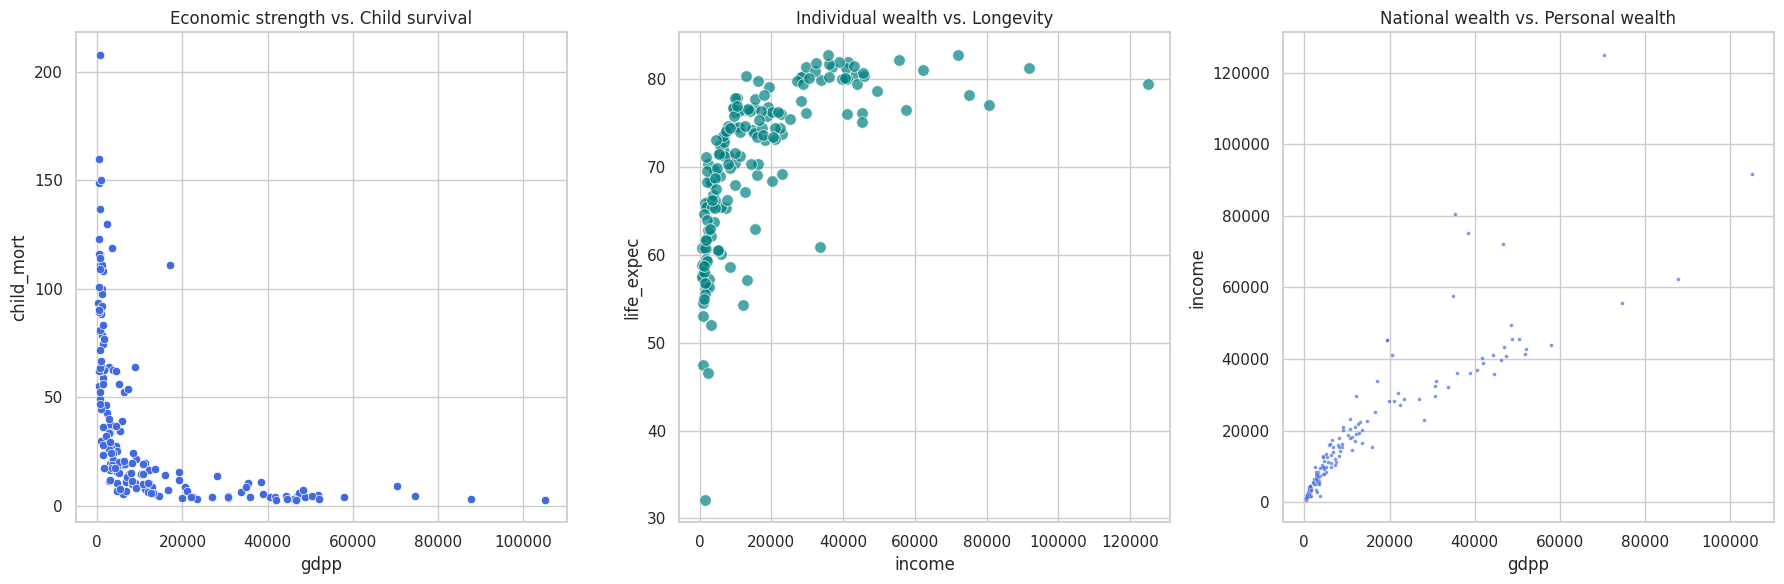

In [9]:
#lets start with Bivariate Analysis
#let's consider three pairs instead of plotting all
# gdpp vs. child_mort (Economic strength vs. Child survival),
# income vs. life_expec (Individual wealth vs. Longevity)
# gdpp vs. income (National wealth vs. Personal wealth — helps spot multicollinearity)

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18,6))

sns.scatterplot(data=df, x='gdpp', y='child_mort', color='royalblue', ax=axes[0])
axes[0].set_title('Economic strength vs. Child survival')
axes[0].set_xlabel('gdpp')
axes[0].set_ylabel('child_mort')

sns.scatterplot(data=df, x='income', y='life_expec', ax=axes[1], color='teal', alpha=0.7, edgecolor='w', s=70)
axes[1].set_title('Individual wealth vs. Longevity')
axes[1].set_xlabel('income')
axes[1].set_ylabel('life_expec')

sns.scatterplot(data=df, x='gdpp', y='income', ax=axes[2], color='royalblue', alpha=0.7, edgecolor='w', s=7)
axes[2].set_title('National wealth vs. Personal wealth')
axes[2].set_xlabel('gdpp')
axes[2].set_ylabel('income')

plt.tight_layout()
plt.show()
#

Inferences
1) gdpp Vs child_mort has  a L shaped curve. It shows that countries with very low gdpp may be less that 5000 show an exponential growth in child mortality raning from 30-150 deaths per 1000 births.
2) Once gdpp crosses 10,000 to 15,000 range, child_mortality drops uniformly near to zero

3) For clustering - we need to find countries with high child_mortality and low gdpp which is top left corner

4) As low income levels life expectancy is also low. But small rise in income increases life expectancy by good amount. After around 30,000 income life_expe reached normal biological ceiling(75-80)

5) Bottom left corner are th countries with less income and less life_expect which badly needs help

6) gdpp vs income shows a perfect linear relation. This feeds same info to the model showing severe multicollinearity.

# Outlier Detectiona and Removal
K-Means calculates distances from a central point (centroid), extreme values heavily distort cluster boundaries. Outliers must be addressed to ensure robust groupings

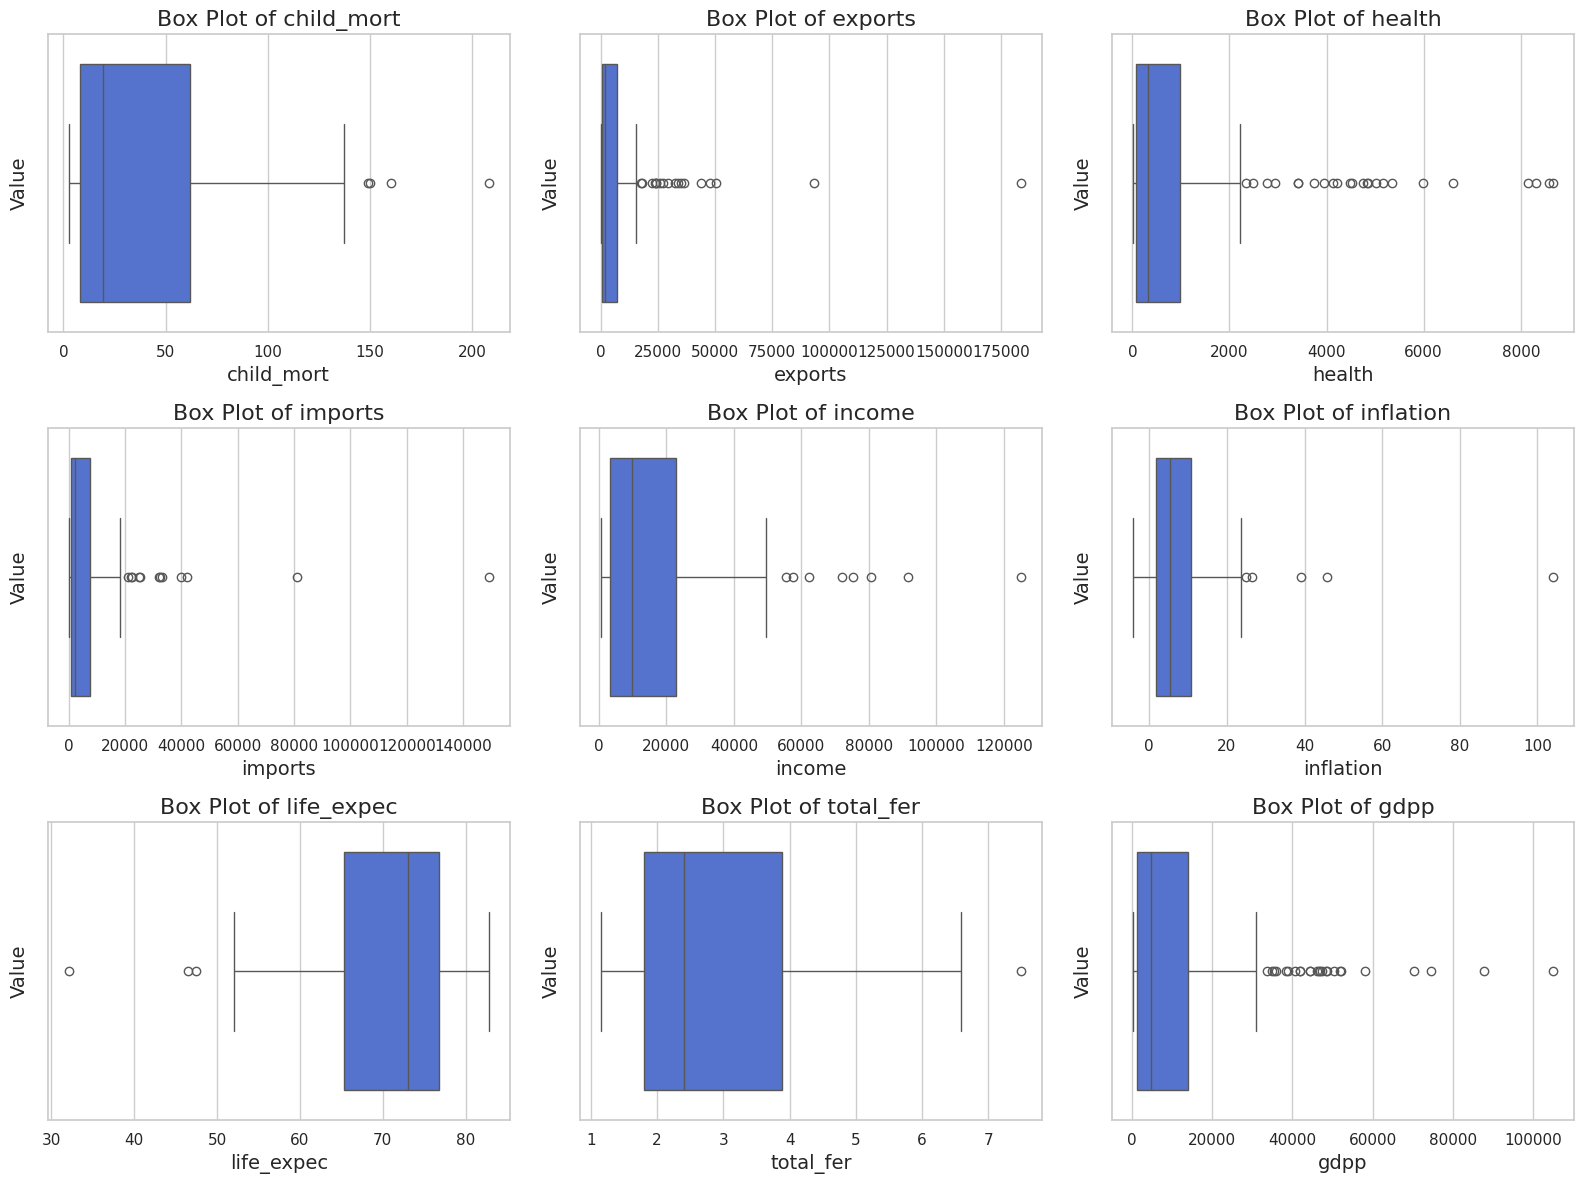

In [10]:
#outlier analysis and removal - construct box plot for all numeric featues
# Plot box plots in a 3x3 grid
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.boxplot(data=df, x=feature, ax=axes[i], color='royalblue')
    axes[i].set_title(f'Box Plot of {feature}', fontsize=16)
    axes[i].set_xlabel(feature, fontsize=14)
    axes[i].set_ylabel('Value', fontsize=14)

plt.tight_layout()


## **Inferences**

1) child_mort and life_expec shows few outliers which might be countries in extrem poverty
2)inflation shows 2-3 outliers which can also be the countries which needs help. So lets not capp this feature also
3) gdpp and income shows outliers which must be developed countries


In [11]:
#as we don't want to find countries which need help the most so we can capp outliers in gdpp, income, import , export and health
#as the outliers shows much developed and luxurious countries.

#we will use winsorization- caps extreme values at a specific percentile threshold, to avoid effect on the K-Means distance metrics
from scipy.stats.mstats import winsorize
threshold_percentile = df['gdpp'].quantile(0.95)
print(threshold_percentile)
#We will cap the outliers to 95% value for analysis.
df['gdpp'][df['gdpp'] > threshold_percentile]=threshold_percentile

threshold_percentile = df['income'].quantile(0.95)
print(threshold_percentile)
#We will cap the outliers to 95% value for analysis.
df['income'][df['income'] > threshold_percentile]=threshold_percentile

threshold_percentile = df['imports'].quantile(0.95)
print(threshold_percentile)
#We will cap the outliers to 95% value for analysis.
df['imports'][df['imports'] > threshold_percentile]=threshold_percentile

threshold_percentile = df['exports'].quantile(0.95)
print(threshold_percentile)
#We will cap the outliers to 95% value for analysis.
df['exports'][df['exports'] > threshold_percentile]  =threshold_percentile

threshold_percentile= df['health'].quantile(0.95)
print(threshold_percentile)
#We will cap the outliers to 95% value for analysis.
df['health'][df['health'] > threshold_percentile]  =threshold_percentile



48610.0
48289.999999999956
24241.559999999972
31385.099999999966
4966.700999999998


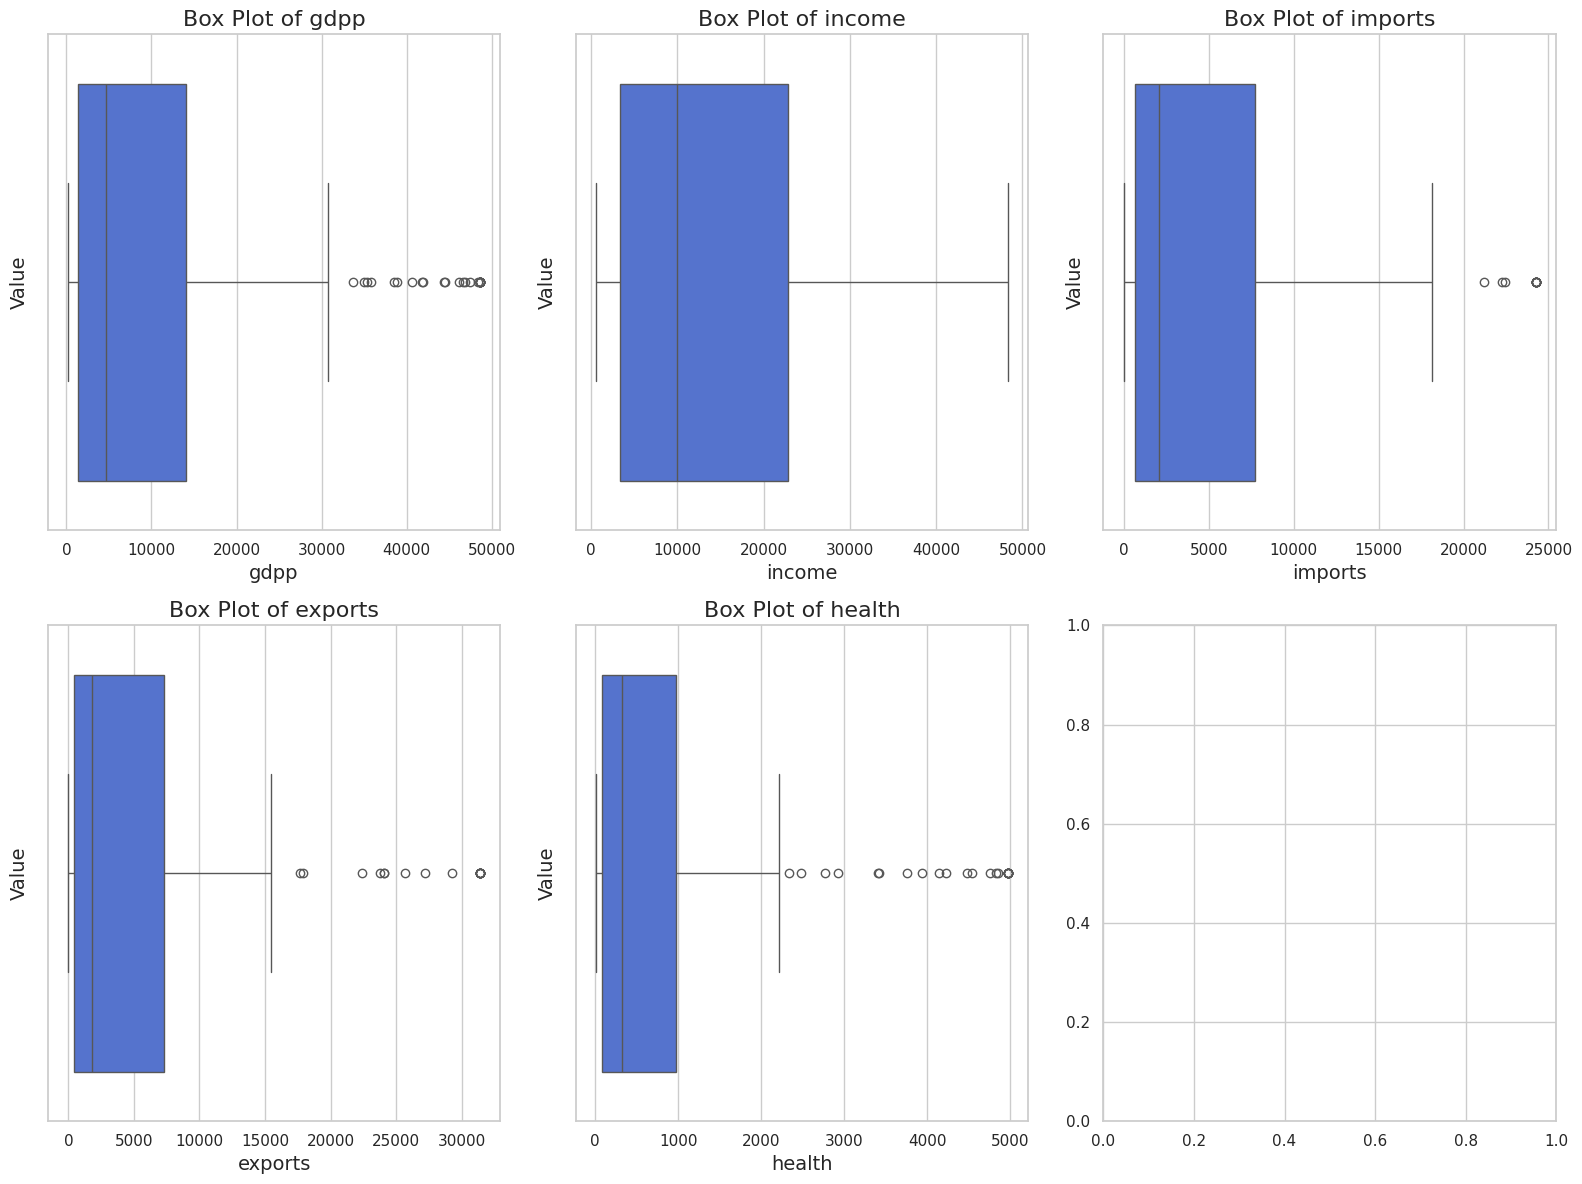

In [12]:
#lets plot again to check outliers

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 12))
axes = axes.flatten()

capped_features= ['gdpp', 'income', 'imports', 'exports', 'health']

for i, feature in enumerate(capped_features):
    sns.boxplot(data=df, x=feature, ax=axes[i], color='royalblue')
    axes[i].set_title(f'Box Plot of {feature}', fontsize=16)
    axes[i].set_xlabel(feature, fontsize=14)
    axes[i].set_ylabel('Value', fontsize=14)

plt.tight_layout()

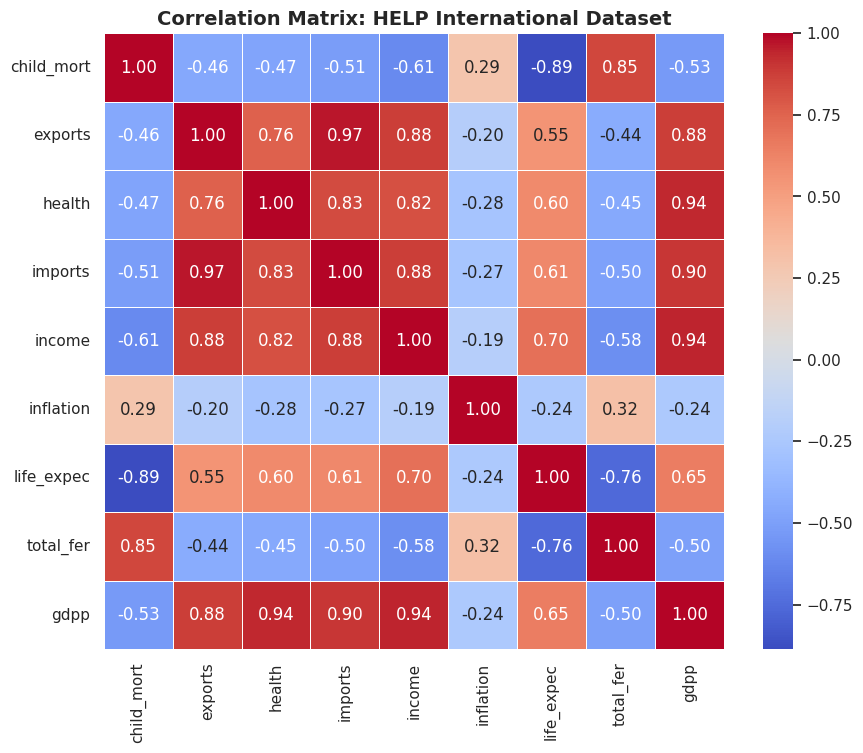

In [13]:
#lets start multicollinearity analysis

# Compute the correlation matrix on your outlier-corrected data (df_clean)
corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix: HELP International Dataset', fontsize=14, weight='bold')
plt.show()

### **Inference**

1) gdpp has exceptionaly high positive collinearity with income, healthm import and exports
2) child_mort and life_expec: Strong negative correlation (-0.89)
3)child_mort and total_fer: High positive correlation(0.85)


In [14]:
#Let's calculate Variance Inflation Factor to decide which features to remove
#VIF measures how much the variance of an estimated regression coefficient is increased because of collinearity

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Isolate numeric columns for VIF calculation
X = df.select_dtypes(include=['float64', 'int64'])

# Calculate initial VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] =X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data.sort_values(by='VIF', ascending=False))
#

      feature        VIF
8        gdpp  64.448451
3     imports  47.577518
1     exports  41.489987
4      income  34.101107
2      health  22.388048
7   total_fer  18.421076
6  life_expec  15.579757
0  child_mort   7.953586
5   inflation   1.944073


# Inferences

1) gdpp and income both shows a countries economic power so they are very much collinear. We can keep gdpp and remove income as it represents entire countries output. And we need this to list needy countries for HELP
2)life_expec (Life Expectancy) and child_mort (Child Mortality) tell the same healthcare story in reverse. so we will remove life_expec and keep child_mort
3)total_fer (Total Fertility Rate) is highly correlated with child_mort.
Remove total_fer (Keep child_mort)


In [15]:
def calculate_vif(dataframe):
    vif = pd.DataFrame()
    vif["feature"] = dataframe.columns
    vif["VIF"] = [variance_inflation_factor(dataframe.values, i) for i in range(dataframe.shape[1])]
    return vif

# Select original features
features_to_keep = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Drop the highly redundant features identified above
features_to_drop = ['income', 'life_expec', 'total_fer']
final_features = [f for f in features_to_keep if f not in features_to_drop]

# Check VIF of the remaining feature set
final_vif = calculate_vif(df[final_features])
print(final_vif.sort_values(by="VIF", ascending=False))

      feature        VIF
3     imports  35.464989
1     exports  30.942156
5        gdpp  27.027321
2      health  16.595024
4   inflation   1.631509
0  child_mort   1.529374


In [16]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler

# Select the non-collinear features filtered from the previous VIF step
X_clean=df[final_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

# Convert back to a DataFrame for easy inspection
X_scaled_df = pd.DataFrame(X_scaled, columns=final_features)
X_scaled_df.head()

,child_mort,exports,health,imports,inflation,gdpp
0,1.291532,-0.669581,-0.629435,-0.732729,0.157336,-0.757362
1,-0.538949,-0.542172,-0.473489,-0.472182,-0.312347,-0.523321
2,-0.272833,-0.475838,-0.530017,-0.560152,0.789274,-0.498838
3,2.007808,-0.418960,-0.588935,-0.543087,1.387054,-0.560376
4,-0.695634,-0.027134,-0.150685,0.306422,-0.601749,0.013312


[1002.0000000000001, 468.72256908034825, 356.43404788527334, 288.62211955122416, 215.99306435404367, 185.64167515542854, 148.0286949901168, 132.38694895574403, 124.39186101455552, 111.80121204582672]


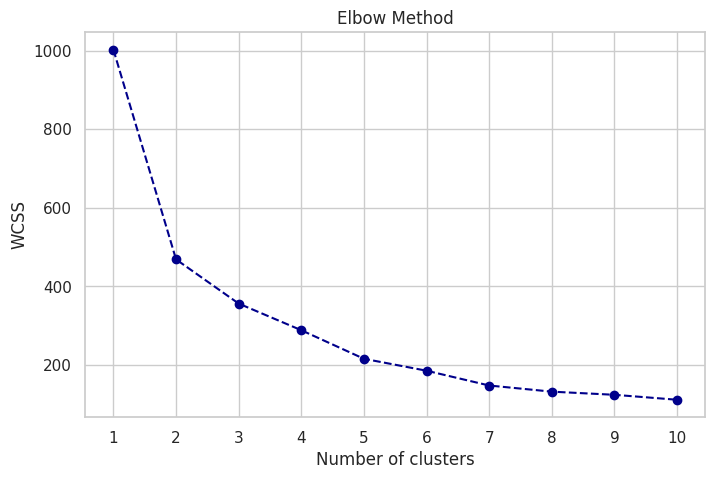

In [17]:
from matplotlib import lines
from matplotlib import markers
#Lets calculate no of clusters using Elbow method uses (WCSS- within cluster sum of squares)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

wcss=[]
K_range=range(1,11)
for k in K_range:
  kmeans= KMeans(n_clusters=k, random_state=42)
  kmeans.fit(X_scaled_df)
  wcss.append(kmeans.inertia_)

print(wcss)
plt.figure(figsize=(8,5))
plt.plot(K_range,wcss, marker='o', linestyle='--', color='darkblue')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.xticks(K_range)
plt.show()


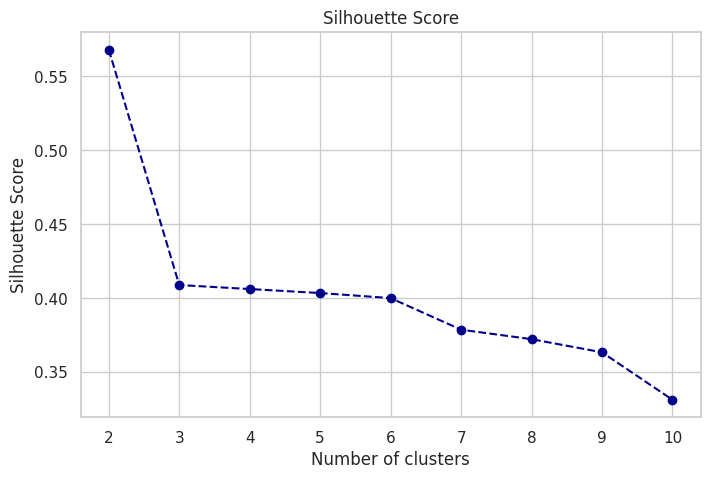

In [18]:
#Lets calculate  Silhouette Score -While the Elbow method looks at cluster tightness internally,
# Silhouette Analysis evaluates both cluster tightness (cohesion) and how well-separated the clusters are from each other (separation)

silhouette_scores=[]
# Silhouette score requires at least 2 clusters to compare boundaries
k_silhouette_range = range(2, 11)
for k in k_silhouette_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, random_state=42)
    cluster_labels = kmeans.fit_predict(X_scaled)
    # Calculate the average silhouette score across all data points
    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)
# Plot the Silhouette Scores
plt.figure(figsize=(8, 5))
plt.plot(k_silhouette_range, silhouette_scores, marker='o', linestyle='--', color='darkblue')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.xticks(k_silhouette_range)

plt.show()

## Inference-
K=3 provides a higher socioeconomic resolution for sorting developing nations than just a binary split(i.e with k=2)

The Elbow Method indicates the drop in inertia slows down significantly after K = 3.
The Silhouette Method hits a highly optimal, clear peak at K = 3.

Therefore we select K = 3 to execute the actual K-Means clustering model.
Developed, DEveloping and UnderDevelopment

In [19]:
#Initialize and Build the Final K-Means Model
# 1. Instantiate the model with K=3
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, random_state=42)
# 2. Fit the model
cluster_assigments= kmeans.fit_predict(X_scaled)
df['ClusterId']=cluster_assigments
print("Final model successfully built. Cluster distributions:\n", df['ClusterId'].value_counts())

Final model successfully built. Cluster distributions:
 ClusterId
0    92
2    39
1    36
Name: count, dtype: int64


In [20]:
#Validate model -we will split 70% training and 30% testing- geometric properties (like cluster density and boundary separations)
#should remain virtually identical when fitting testing and training data
from sklearn.model_selection import train_test_split

# Split the scaled feature matrix (70% train, 30% test)
X_train, X_test = train_test_split(X_scaled, test_size=0.30, random_state=101)
print(f"Training shape: {X_train.shape} | Testing shape: {X_test.shape}")

#Fit model to train and test data
validation_kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, random_state=42)
train_labels= validation_kmeans.fit(X_train)
print("train labels:", train_labels)


# Extract cluster assignments for the training rows
train_preds = validation_kmeans.labels_
print("train pred", train_preds)

# Calculate Silhouette Score for the training data
train_silhouette = silhouette_score(X_train, train_preds)
print(f"Training Data Silhouette Score: {train_silhouette:.4f}")

## Predict cluster assignments for the unseen test data based on training centroids
test_preds = validation_kmeans.predict(X_test)
print("test preds", test_preds)

# Calculate Silhouette Score for the test data
test_silhouette = silhouette_score(X_test, test_preds)
print(f"Test Data Silhouette Score: {test_silhouette:.4f}")

Training shape: (116, 6) | Testing shape: (51, 6)
train labels: KMeans(n_clusters=3, random_state=42)
train pred [1 0 1 1 1 0 0 1 2 1 0 1 0 0 1 1 1 0 1 2 1 1 1 1 1 0 1 2 0 1 1 1 0 2 1 0 1
 0 0 2 0 1 0 0 1 2 0 1 0 1 1 1 1 0 0 1 0 0 1 1 0 0 0 0 1 2 1 1 0 1 2 0 0 0
 0 1 1 2 1 0 0 0 2 1 1 0 0 1 1 0 0 0 2 0 0 1 0 2 0 0 2 0 1 2 1 1 0 0 0 2 0
 0 0 0 1 1]
Training Data Silhouette Score: 0.3113
test preds [1 1 2 0 1 1 0 2 1 1 0 1 0 2 1 1 0 2 0 0 0 0 1 0 0 0 1 1 1 1 1 1 1 2 2 0 0
 2 2 2 0 2 1 1 0 0 1 0 0 2 2]
Test Data Silhouette Score: 0.3821


## Inferences

Evaluation of cluster stability
lets look at the difference between our training and testing score
train_silhouette and test_silhouette scores are close to each other i.e. 0.3113 and 0.3821
so we can say model is stable

In [21]:
#Profile the Clusters and interpret the socioeconomic averages of each group

#lets map cluster id back to raw data
#To interpret what the clusters actually mean, you must evaluate them using the original, unscaled, and uncapped metrics
df['Cluster_ID'] = cluster_assigments
# Count how many countries fell into each group
print("Country distribution across clusters:")
print(df['Cluster_ID'].value_counts())
#Calculate the mean (average) values of the key health and economic indicators for each cluster. This summarizes the distinct profile of each group.
# Group by Cluster_ID and calculate the mean for all numeric columns
cluster_profiles = df.groupby('Cluster_ID').mean(numeric_only=True)
# Sort by child_mortality descending to easily rank groups by urgency of need
cluster_profiles = cluster_profiles.sort_values(by='child_mort', ascending=False)
# Display the clean profile matrix
print("\n--- CLUSTER PROFILE MATRIX ---")
print(cluster_profiles[['child_mort', 'income', 'gdpp', 'health', 'life_expec']].round(2))



Country distribution across clusters:
Cluster_ID
0    92
2    39
1    36
Name: count, dtype: int64

--- CLUSTER PROFILE MATRIX ---
            child_mort    income      gdpp   health  life_expec
Cluster_ID                                                     
2               100.62   3420.33   1628.67    81.27       58.91
0                24.80  11997.50   6134.74   386.98       71.77
1                 5.14  38644.72  38219.17  3348.58       80.07


## Inferences
1) Cluster ID 2 is the group of countries which are under developed with high child mortality(100.62), low income(3420), low gdpp(1628) and low health expences(81) and low life expectency (58.91)
2)These nations face severe systemic poverty, inadequate medical infrastructure, and economic distres
3) This cluster represents the primary target for HELP International
4) Cluster ID =0 is the group of nations on second priority
5)Cluster ID=1 is wealthier countries with established healthcare systems

In [37]:
#Lets extract the final list of countries
highurgency_clusterId= cluster_profiles['child_mort'].idxmax()

#print(df[df['Cluster_ID']==highurgency_clusterId].sort_values(by='child_mort', ascending=False))
#
target_countries=df[df['Cluster_ID']==highurgency_clusterId].sort_values(by='child_mort', ascending=False, ignore_index=True)
print(f"\nTotal countries requiring immediate aid: {len(target_countries)}")
print("Sample list of high-priority nations:")
print(target_countries[:10])



Total countries requiring immediate aid: 39
Sample list of high-priority nations:
                    country  child_mort   exports    health   imports  income  \
0                     Haiti       208.0   101.286   45.7442   428.314  1500.0   
1              Sierra Leone       160.0    67.032   52.2690   137.655  1220.0   
2                      Chad       150.0   330.096   40.6341   390.195  1930.0   
3  Central African Republic       149.0    52.628   17.7508   118.190   888.0   
4                      Mali       137.0   161.424   35.2584   248.508  1870.0   
5                   Nigeria       130.0   589.490  118.1310   405.420  5150.0   
6                     Niger       123.0    77.256   17.9568   170.868   814.0   
7                    Angola       119.0  2199.190  100.6050  1514.370  5900.0   
8              Burkina Faso       116.0   110.400   38.7550   170.200  1430.0   
9          Congo, Dem. Rep.       116.0   137.274   26.4194   165.664   609.0   

   inflation  life_expec 

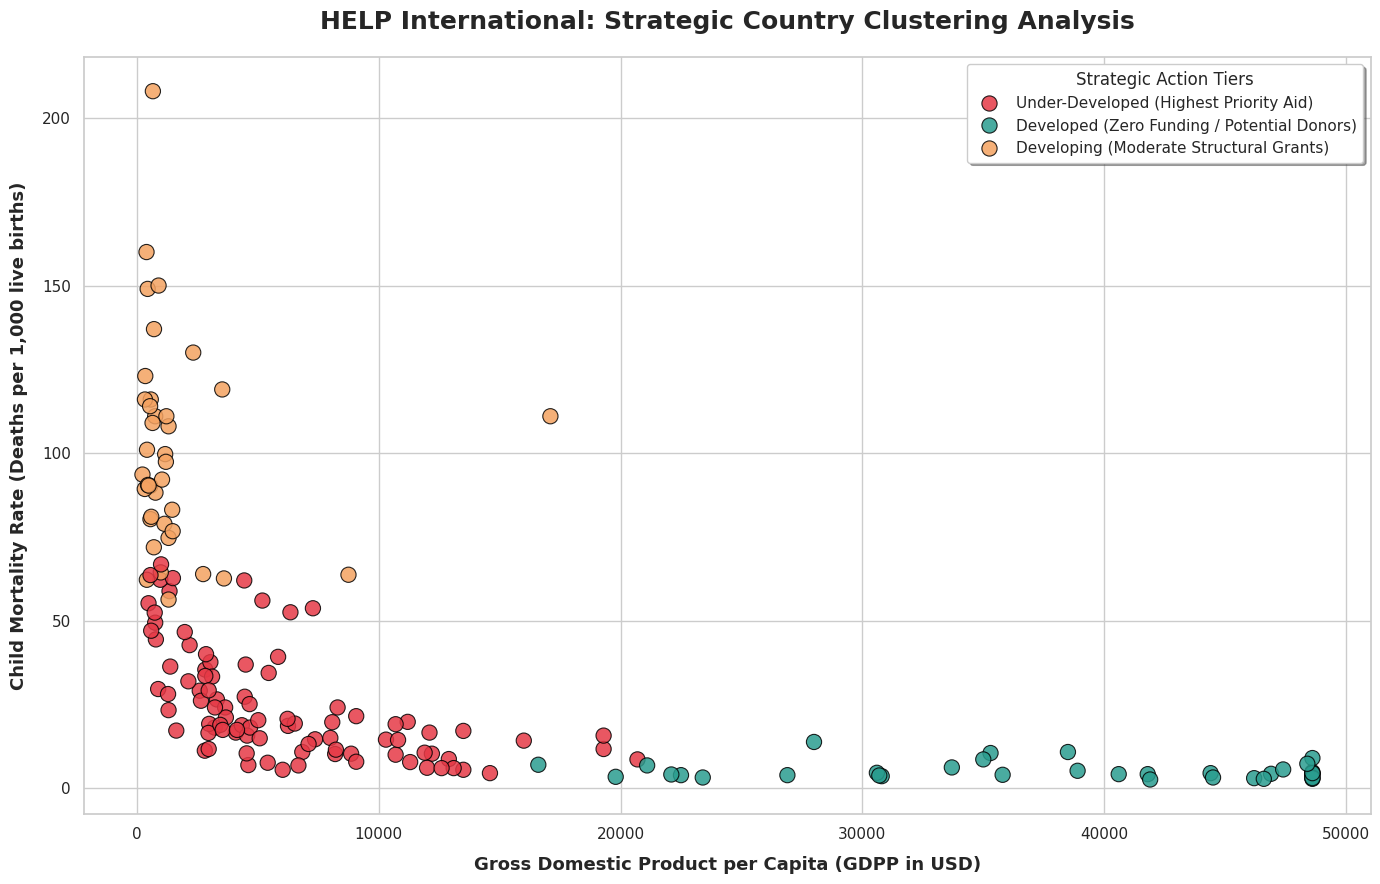

In [38]:
#let plot gdpp against Child Mortality while overlaying the assigned cluster colors

# 1. Set up a clean, professional presentation theme
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 9))

# 2. color palette for clusters
# Red/Crimson for high urgency, Amber/Orange for medium, Teal/Blue for stable
cluster_colors = {
    2: "#F4A261",   # Amber Orange: Developing (Moderate Urgency)
    1: "#2A9D8F", # Deep Teal: Developed (Stable / Low Urgency)
    0: "#E63946"   #  Crimson Red: Under-Developed (High Urgency)
}
# 3. Plot
scatter_plot= sns.scatterplot(data=df, x='gdpp', y='child_mort', hue='Cluster_ID', palette=cluster_colors,
    s=120,                 # Large dot size for visibility on slides
    alpha=0.85,             # Slight transparency to handle overlapping dots
    edgecolor='black',      # Sharp borders around data points
    linewidth=0.8)
# 4. Add labels for clarity
plt.title('HELP International: Strategic Country Clustering Analysis', fontsize=18, weight='bold', pad=20)
plt.xlabel('Gross Domestic Product per Capita (GDPP in USD)', fontsize=13, weight='semibold', labelpad=10)
plt.ylabel('Child Mortality Rate (Deaths per 1,000 live births)', fontsize=13, weight='semibold', labelpad=10)

# 6. Customize the legend for business stakeholders (Replacing raw 0, 1, 2 IDs)
handles, labels = scatter_plot.get_legend_handles_labels()
business_labels = [
    'Under-Developed (Highest Priority Aid)',
    'Developed (Zero Funding / Potential Donors)',
    'Developing (Moderate Structural Grants)'
]
plt.legend(handles, business_labels, title="Strategic Action Tiers",
           title_fontsize='12', fontsize='11', loc='upper right',
           frameon=True, shadow=True, facecolor='white')
plt.tight_layout()
plt.show()